In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("imdb_top_1000.csv")

In [3]:
df.shape

(1000, 16)

In [4]:
df.head()

,Poster_Link,Series_Title,Released_Year,Certificate,Runtime,Genre,IMDB_Rating,Overview,Meta_score,Director,Star1,Star2,Star3,Star4,No_of_Votes,Gross
0,https://m.media-amazon.com/images/M/MV5BMDFkYT...,The Shawshank Redemption,1994,A,142 min,Drama,9.3,Two imprisoned men bond over a number of years...,80.0,Frank Darabont,Tim Robbins,Morgan Freeman,Bob Gunton,William Sadler,2343110,"28,341,469"
1,https://m.media-amazon.com/images/M/MV5BM2MyNj...,The Godfather,1972,A,175 min,"Crime, Drama",9.2,An organized crime dynasty's aging patriarch t...,100.0,Francis Ford Coppola,Marlon Brando,Al Pacino,James Caan,Diane Keaton,1620367,"134,966,411"
2,https://m.media-amazon.com/images/M/MV5BMTMxNT...,The Dark Knight,2008,UA,152 min,"Action, Crime, Drama",9.0,When the menace known as the Joker wreaks havo...,84.0,Christopher Nolan,Christian Bale,Heath Ledger,Aaron Eckhart,Michael Caine,2303232,"534,858,444"
3,https://m.media-amazon.com/images/M/MV5BMWMwMG...,The Godfather: Part II,1974,A,202 min,"Crime, Drama",9.0,The early life and career of Vito Corleone in ...,90.0,Francis Ford Coppola,Al Pacino,Robert De Niro,Robert Duvall,Diane Keaton,1129952,"57,300,000"
4,https://m.media-amazon.com/images/M/MV5BMWU4N2...,12 Angry Men,1957,U,96 min,"Crime, Drama",9.0,A jury holdout attempts to prevent a miscarria...,96.0,Sidney Lumet,Henry Fonda,Lee J. Cobb,Martin Balsam,John Fiedler,689845,"4,360,000"


In [5]:
# data cleaning
df["Gross"] = df["Gross"].str.replace(",", "").astype(float)

In [6]:
all_genres = set(g.strip() for genres in df["Genre"] for g in genres.split(","))
for genre in all_genres:
    df[genre] = df["Genre"].apply(lambda x: 1 if genre in x else 0)

In [7]:
genre_counts = df[list(all_genres)].sum().sort_values(ascending=False)
print("\n按体裁统计电影数量：")
print(genre_counts)


按体裁统计电影数量：
Drama        724
Comedy       233
Crime        209
Adventure    196
Action       189
Thriller     137
Romance      125
Biography    109
Mystery       99
Animation     82
Sci-Fi        67
Fantasy       66
Family        56
History       56
War           51
Music         47
Horror        32
Western       20
Film-Noir     19
Sport         19
Musical       17
dtype: int64


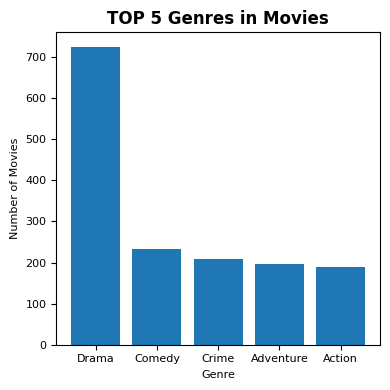

In [8]:
# 前一千部电影里的drama数量最多

import pandas as pd
genre_counts_df = pd.DataFrame(genre_counts,columns=["Count"]).head(5)

# 绘制柱状图
plt.figure(figsize=(4, 4))
plt.bar(genre_counts_df.index, genre_counts_df["Count"])
plt.xticks(fontsize=8)
plt.xlabel("Genre", fontsize=8)
plt.yticks(fontsize=8)
plt.ylabel("Number of Movies", fontsize=8)
plt.title("TOP 5 Genres in Movies", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

<ipython-input-9-882f844e8f7d>:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top_genres.loc["Others"] = others
<ipython-input-9-882f844e8f7d>:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top_genres["Percentage"] = (top_genres["Count"] / top_genres["Count"].sum()) * 100


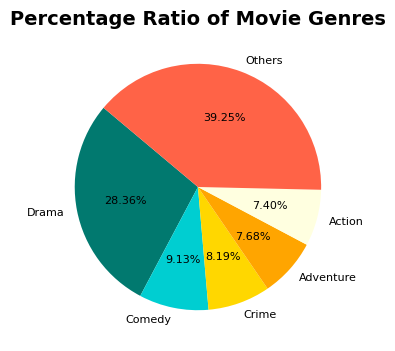

In [9]:
import pandas as pd
import seaborn as sns
genre_counts_df = pd.DataFrame(genre_counts,columns=["Count"])

top_n = 5  # 选择前 5 个主要体裁
top_genres = genre_counts_df.head(top_n)
others = genre_counts_df.iloc[top_n:].sum()  # 计算其他体裁的总数
top_genres.loc["Others"] = others

# 计算百分比
top_genres["Percentage"] = (top_genres["Count"] / top_genres["Count"].sum()) * 100

# 绘制饼图
plt.figure(figsize=(4, 4))
# colors = sns.color_palette("colorblind", len(top_genres))
colors = ["#01796F", "#00CED1", "#FFD700", "#FFA500", "#FFFFE0", "#FF6347"]

plt.pie(
    top_genres["Percentage"],
    labels=top_genres.index,
    autopct="%.2f%%",
    startangle=140,
    colors = colors,
    textprops={"fontsize": 8}
)

# 添加标题
plt.title("Percentage Ratio of Movie Genres", fontsize=14, fontweight="bold")
plt.show()

In [10]:
# 前一千部电影里的Adventure票房最高

In [11]:
gross_by_genre = {genre: df.loc[df[genre] == 1, "Gross"].mean() for genre in all_genres}
print("\n按体裁统计总票房：")
print(pd.Series(gross_by_genre).sort_values(ascending=False))


按体裁统计总票房：
Adventure    1.657313e+08
Sci-Fi       1.480264e+08
Action       1.412393e+08
Animation    1.279675e+08
Fantasy      1.086168e+08
Family       9.293266e+07
Comedy       6.412530e+07
Thriller     5.867663e+07
History      5.553953e+07
Biography    5.525602e+07
Sport        5.367202e+07
Western      5.351884e+07
Drama        4.605967e+07
Mystery      4.127438e+07
Crime        4.068014e+07
Romance      4.035885e+07
Horror       4.000236e+07
War          3.807829e+07
Music        3.026781e+07
Musical      2.019933e+07
Film-Noir    4.872073e+06
dtype: float64


In [12]:
# 前一千部电影里的Adventure评分最高

In [13]:
rating_by_genre = {genre: df.loc[df[genre] == 1, "IMDB_Rating"].mean() for genre in all_genres}
print("\n按体裁统计总票房：")
print(pd.Series(rating_by_genre).sort_values(ascending=False))


按体裁统计总票房：
War          8.013725
Western      8.000000
Film-Noir    7.989474
Sci-Fi       7.977612
Mystery      7.967677
Drama        7.959392
Crime        7.954545
History      7.953571
Adventure    7.952041
Action       7.948677
Musical      7.947059
Music        7.940426
Biography    7.935780
Fantasy      7.931818
Animation    7.930488
Sport        7.926316
Romance      7.925600
Family       7.912500
Thriller     7.909489
Comedy       7.903433
Horror       7.887500
dtype: float64


In [14]:
df = pd.read_csv("imdb_top_1000.csv")

In [15]:
df = df.drop(columns = ['Certificate','Gross','Poster_Link','Meta_score'])

In [16]:
# 基于评分

In [17]:
# 避免投票人数少的电影因评分高而被推荐

min_vote = df['No_of_Votes'].quantile(.9) # 699297.7
mean_vote = df['IMDB_Rating'].mean() # 7.942

In [18]:
max_vote_movies = df.loc[df['No_of_Votes'] >= min_vote]
max_vote_movies.shape

(100, 12)

In [19]:
def simple_recommender(x , mean_ = mean_vote , min_ = min_vote):
    rate = x['IMDB_Rating']
    voters = x['No_of_Votes']
    return ( ( voters / (voters + min_) * rate ) + ( min_ / (voters + min_) * mean_ ) )

In [20]:
max_vote_movies = max_vote_movies.assign(weighted_avg=max_vote_movies.apply(simple_recommender, axis=1))
max_vote_movies = max_vote_movies.sort_values('weighted_avg' ,ascending = False )
max_vote_movies = max_vote_movies.round({'weighted_avg': 2})
max_vote_movies[['Series_Title','Released_Year','IMDB_Rating','weighted_avg']].head(10)

,Series_Title,Released_Year,IMDB_Rating,weighted_avg
0,The Shawshank Redemption,1994,9.3,8.99
1,The Godfather,1972,9.2,8.82
2,The Dark Knight,2008,9.0,8.76
6,Pulp Fiction,1994,8.9,8.64
5,The Lord of the Rings: The Return of the King,2003,8.9,8.62
3,The Godfather: Part II,1974,9.0,8.60
8,Inception,2010,8.8,8.58
9,Fight Club,1999,8.8,8.57
11,Forrest Gump,1994,8.8,8.56
7,Schindler's List,1993,8.9,8.55


In [21]:
df['Overview'].head(5)

,Overview
0,Two imprisoned men bond over a number of years...
1,An organized crime dynasty's aging patriarch t...
2,When the menace known as the Joker wreaks havo...
3,The early life and career of Vito Corleone in ...
4,A jury holdout attempts to prevent a miscarria...


**Based on content**

In [22]:
df[df["Series_Title"] == "12 Angry Men"]

,Series_Title,Released_Year,Runtime,Genre,IMDB_Rating,Overview,Director,Star1,Star2,Star3,Star4,No_of_Votes
4,12 Angry Men,1957,96 min,"Crime, Drama",9.0,A jury holdout attempts to prevent a miscarria...,Sidney Lumet,Henry Fonda,Lee J. Cobb,Martin Balsam,John Fiedler,689845


In [23]:
from sklearn.feature_extraction.text import TfidfVectorizer,CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity,linear_kernel

In [24]:
tfidf = TfidfVectorizer(stop_words='english')
tfidf_matrix = tfidf.fit_transform(df['Overview'])
tfidf_matrix.shape

(1000, 5426)

In [25]:
sim_vec = linear_kernel(tfidf_matrix, tfidf_matrix)

In [26]:
indexes = pd.Series(df.index , index = df['Series_Title'])

In [27]:
def recommend_movies(x, sim_vec):
    id_ = indexes[x]
    sim_movies = list(enumerate(sim_vec[id_]))
    sim_movies = sorted(sim_movies, key=lambda x: x[1], reverse=True)
    sim_movies = sim_movies[1:6]
    R_movies = [i[0] for i in sim_movies]
    return df[['Series_Title', 'Genre', 'Overview']].iloc[R_movies]

In [28]:
recommend_movies('12 Angry Men' , sim_vec)
# 12 Angry Men : A jury holdout attempts to prevent a miscarriage of justice by forcing his colleagues to reconsider the evidence.

,Series_Title,Genre,Overview
791,Road to Perdition,"Crime, Drama, Thriller","A mob enforcer's son witnesses a murder, forci..."
95,Amélie,"Comedy, Romance",Amélie is an innocent and naive girl in Paris ...
69,Memento,"Mystery, Thriller",A man with short-term memory loss attempts to ...
40,American History X,Drama,A former neo-nazi skinhead tries to prevent hi...
495,The Man from Earth,"Drama, Fantasy, Mystery",An impromptu goodbye party for Professor John ...


In [29]:
import torch
from transformers import BertTokenizer, BertModel
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity


tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
model = BertModel.from_pretrained("bert-base-uncased")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

def encode_overview(text):
    tokens = tokenizer(
        text,
        max_length=128,
        padding="max_length",
        truncation=True,
        return_tensors="pt"
    )

    tokens = {key: val.to(device) for key, val in tokens.items()}

    with torch.no_grad():
        outputs = model(**tokens)
        cls_embedding = outputs.last_hidden_state[:, 0, :]
    return cls_embedding.cpu().numpy()

df["Embedding"] = df["Overview"].apply(encode_overview)

embeddings = torch.cat([torch.tensor(embed) for embed in df["Embedding"].tolist()], dim=0).numpy()
similarity_matrix = cosine_similarity(embeddings, embeddings)

def recommend_movies(movie_title, similarity_matrix, df, top_n=5):
    idx = df[df["Series_Title"] == movie_title].index[0]
    sim_scores = list(enumerate(similarity_matrix[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    sim_indices = [i[0] for i in sim_scores[1:top_n+1]]
    return df.iloc[sim_indices][["Series_Title", "Overview"]]


movie_to_recommend = "12 Angry Men"
recommendations = recommend_movies(movie_to_recommend, similarity_matrix, df, top_n=5)


print(f"Movie recommendations based on the movie < {movie_to_recommend} >")
recommendations

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Movie recommendations based on the movie < 12 Angry Men >


,Series_Title,Overview
87,Drishyam,A man goes to extreme lengths to save his fami...
838,The Verdict,A lawyer sees the chance to salvage his career...
280,Network,A television network cynically exploits a dera...
556,Strangers on a Train,A psychopath forces a tennis star to comply wi...
903,A Star Is Born,A musician helps a young singer find fame as a...
